# Part 1 — Step 4: Feature Engineering
**Techniques applied:**
- Extraction: correlation analysis, variance threshold
- Selection: feature importance via RandomForest
- Projection (dimensionality reduction):
  - **PCA** — Principal Component Analysis (unsupervised)
  - **LDA-inspired projection** — Linear Discriminant Analysis adapted for regression via target discretisation

Run after `agriculture_cleaning.ipynb`.

In [1]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Cell 2 : Load clean scaled data ───────────────────────────────────────────
df_std = pd.read_csv('datasets/dataset1_clean_std.csv')

TARGET_COLS  = ['water_allocation_L_ha', 'fertilizer_N_kg_ha', 'fertilizer_P_kg_ha']
FEATURE_COLS = [c for c in df_std.columns if c not in TARGET_COLS]

X = df_std[FEATURE_COLS].values
y = df_std[TARGET_COLS].values

# Individual target vectors (for univariate analysis)
y_water = df_std['water_allocation_L_ha'].values
y_N     = df_std['fertilizer_N_kg_ha'].values
y_P     = df_std['fertilizer_P_kg_ha'].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features: {FEATURE_COLS}")

X shape : (1989, 17)
y shape : (1989, 3)
Features: ['temperature_C', 'humidity_pct', 'rainfall_mm', 'soil_moisture_pct', 'soil_pH', 'nitrogen_mgkg', 'phosphorus_mgkg', 'potassium_mgkg', 'field_area_ha', 'growth_stage_enc', 'soil_type_Loam', 'soil_type_Sandy', 'soil_type_Silty', 'crop_type_Potato', 'crop_type_Sunflower', 'crop_type_Tomato', 'crop_type_Wheat']


---
## Part A — Feature Extraction & Selection

In [3]:
# ── Cell 3 : Variance Threshold — remove near-zero variance features ──────────
#
# Features with very low variance carry almost no information.
# Threshold = 0.01 (after StandardScaling, all features should have variance ~1;
# binary OHE columns may be much lower if one class is very rare).
# ─────────────────────────────────────────────────────────────────────────────

vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)

kept_mask    = vt.get_support()
kept_cols    = [FEATURE_COLS[i] for i, k in enumerate(kept_mask) if k]
removed_cols = [FEATURE_COLS[i] for i, k in enumerate(kept_mask) if not k]

print(f"Original features : {len(FEATURE_COLS)}")
print(f"After VarianceThreshold: {len(kept_cols)} kept, {len(removed_cols)} removed")
if removed_cols:
    print(f"Removed: {removed_cols}")
else:
    print("No feature removed — all have sufficient variance.")

Original features : 17
After VarianceThreshold: 17 kept, 0 removed
No feature removed — all have sufficient variance.


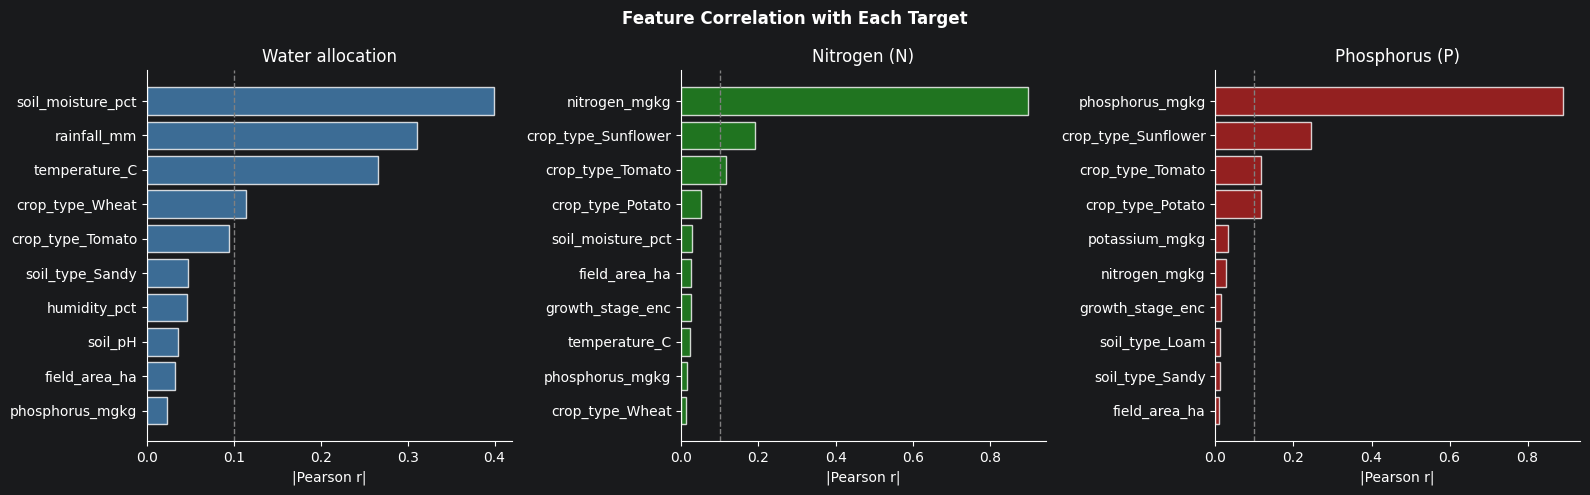

Top 5 features correlated with water allocation:
soil_moisture_pct    0.399719
rainfall_mm          0.310838
temperature_C        0.265459
crop_type_Wheat      0.114068
crop_type_Tomato     0.093930
dtype: float64


In [4]:
# ── Cell 4 : Correlation with targets ─────────────────────────────────────────
df_feat = pd.DataFrame(X, columns=FEATURE_COLS)
df_feat['water_allocation_L_ha'] = y_water
df_feat['fertilizer_N_kg_ha']    = y_N
df_feat['fertilizer_P_kg_ha']    = y_P

corr_water = df_feat[FEATURE_COLS].corrwith(df_feat['water_allocation_L_ha']).abs().sort_values(ascending=False)
corr_N     = df_feat[FEATURE_COLS].corrwith(df_feat['fertilizer_N_kg_ha']).abs().sort_values(ascending=False)
corr_P     = df_feat[FEATURE_COLS].corrwith(df_feat['fertilizer_P_kg_ha']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Correlation with Each Target', fontsize=12, fontweight='bold')

for ax, corr, title, color in zip(
    axes,
    [corr_water, corr_N, corr_P],
    ['Water allocation', 'Nitrogen (N)', 'Phosphorus (P)'],
    ['steelblue', 'forestgreen', 'firebrick']
):
    top10 = corr.head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('|Pearson r|')
    ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='r=0.1 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fe_correlation.png', dpi=120)
plt.show()

print("Top 5 features correlated with water allocation:")
print(corr_water.head())

In [5]:
# ── Cell 5 : SelectKBest (F-regression) for each target ──────────────────────
#
# Uses ANOVA F-statistic to select features most linearly related to each target.
# ─────────────────────────────────────────────────────────────────────────────

K = 10   # number of best features to keep

selector_water = SelectKBest(f_regression, k=K).fit(X, y_water)
selector_N     = SelectKBest(f_regression, k=K).fit(X, y_N)
selector_P     = SelectKBest(f_regression, k=K).fit(X, y_P)

best_water = [FEATURE_COLS[i] for i in selector_water.get_support(indices=True)]
best_N     = [FEATURE_COLS[i] for i in selector_N.get_support(indices=True)]
best_P     = [FEATURE_COLS[i] for i in selector_P.get_support(indices=True)]

# Union of all top features across three targets
best_union = list(set(best_water) | set(best_N) | set(best_P))

print(f"Top {K} for water  : {best_water}")
print(f"Top {K} for N      : {best_N}")
print(f"Top {K} for P      : {best_P}")
print(f"\nUnion (all targets): {len(best_union)} features")
print(best_union)

Top 10 for water  : ['temperature_C', 'humidity_pct', 'rainfall_mm', 'soil_moisture_pct', 'soil_pH', 'phosphorus_mgkg', 'field_area_ha', 'soil_type_Sandy', 'crop_type_Tomato', 'crop_type_Wheat']
Top 10 for N      : ['temperature_C', 'soil_moisture_pct', 'nitrogen_mgkg', 'phosphorus_mgkg', 'field_area_ha', 'growth_stage_enc', 'crop_type_Potato', 'crop_type_Sunflower', 'crop_type_Tomato', 'crop_type_Wheat']
Top 10 for P      : ['nitrogen_mgkg', 'phosphorus_mgkg', 'potassium_mgkg', 'field_area_ha', 'growth_stage_enc', 'soil_type_Loam', 'soil_type_Sandy', 'crop_type_Potato', 'crop_type_Sunflower', 'crop_type_Tomato']

Union (all targets): 16 features
['soil_type_Loam', 'soil_moisture_pct', 'temperature_C', 'soil_type_Sandy', 'growth_stage_enc', 'crop_type_Tomato', 'potassium_mgkg', 'soil_pH', 'humidity_pct', 'field_area_ha', 'nitrogen_mgkg', 'crop_type_Sunflower', 'crop_type_Wheat', 'rainfall_mm', 'crop_type_Potato', 'phosphorus_mgkg']


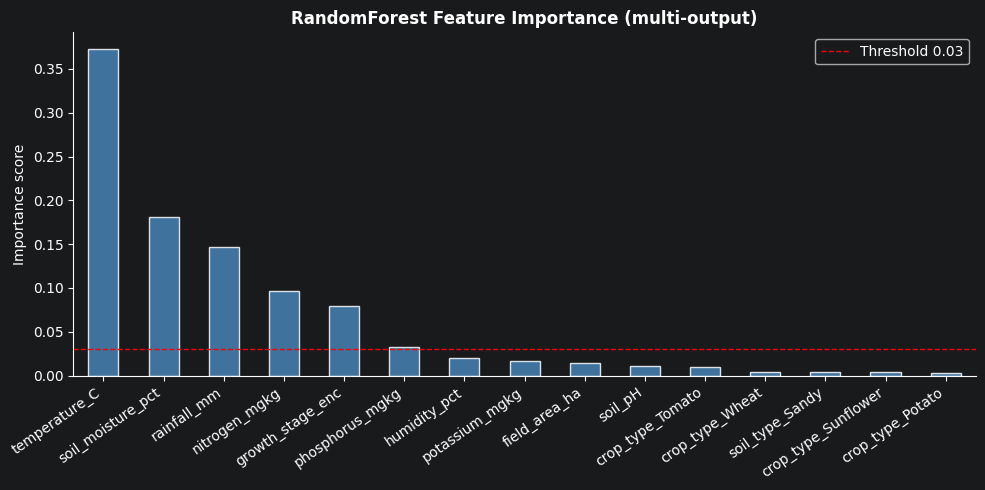

Features with importance >= 0.03: ['temperature_C', 'soil_moisture_pct', 'rainfall_mm', 'nitrogen_mgkg', 'growth_stage_enc', 'phosphorus_mgkg']


In [6]:
# ── Cell 6 : RandomForest feature importance (multi-output) ──────────────────
#
# Trains a quick RandomForest on all 3 targets simultaneously.
# Importance = mean decrease in impurity across all trees and all outputs.
# ─────────────────────────────────────────────────────────────────────────────

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('RandomForest Feature Importance (multi-output)', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance score')
ax.axhline(0.03, color='red', linestyle='--', linewidth=1, label='Threshold 0.03')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fe_importance.png', dpi=120)
plt.show()

# Keep features above threshold
THRESHOLD_IMP = 0.03
selected_by_rf = importances[importances >= THRESHOLD_IMP].index.tolist()
print(f"Features with importance >= {THRESHOLD_IMP}: {selected_by_rf}")

In [7]:
# ── Cell 7 : Build X_selected — consensus best features ──────────────────────
#
# Consensus: features selected by BOTH RandomForest importance AND SelectKBest union.
# This gives a robust, double-validated feature set.
# ─────────────────────────────────────────────────────────────────────────────

consensus_features = list(set(selected_by_rf) & set(best_union))

# Fallback: if consensus is too small, use RF selection only
if len(consensus_features) < 5:
    consensus_features = selected_by_rf
    print("Consensus too small — using RF selection only.")

print(f"Final selected features ({len(consensus_features)}): {sorted(consensus_features)}")

X_selected = df_std[consensus_features].values
print(f"X_selected shape: {X_selected.shape}")

Final selected features (6): ['growth_stage_enc', 'nitrogen_mgkg', 'phosphorus_mgkg', 'rainfall_mm', 'soil_moisture_pct', 'temperature_C']
X_selected shape: (1989, 6)


---
## Part B — PCA (Principal Component Analysis)

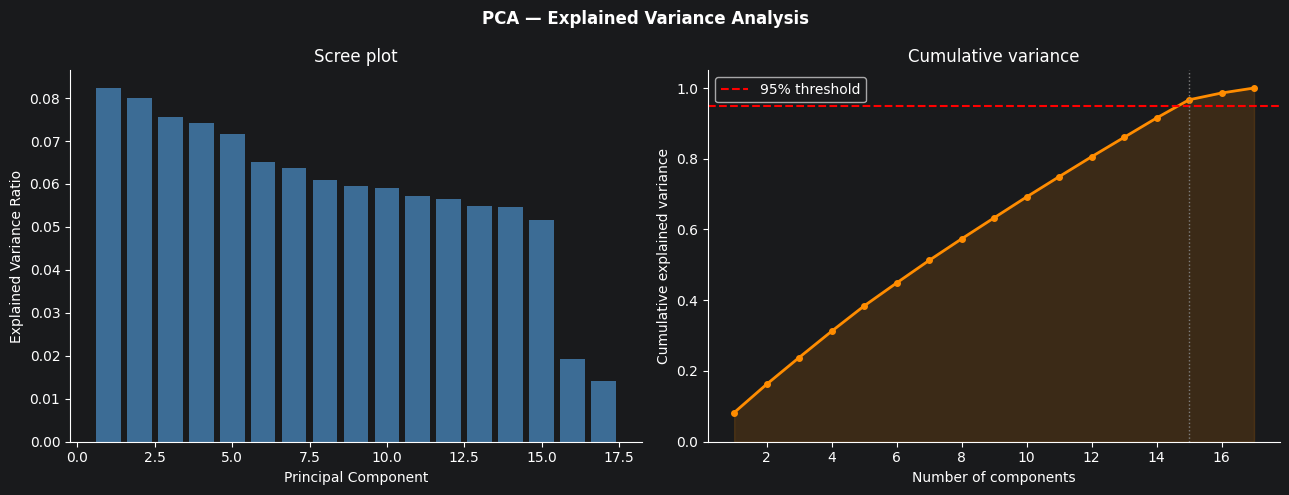

Components needed for 95% variance : 15
Original dimensions                : 17
Reduction ratio                    : 11.8%


In [8]:
# ── Cell 8 : PCA — explained variance analysis ────────────────────────────────
#
# Step 1: Fit PCA on ALL features to see how many components explain 95% variance.
# Step 2: Refit with that number of components.
# ─────────────────────────────────────────────────────────────────────────────

pca_full = PCA(random_state=42)
pca_full.fit(X)

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)

# Find minimum components for 95% variance
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA — Explained Variance Analysis', fontsize=12, fontweight='bold')

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree plot')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', color='darkorange', linewidth=2, markersize=4)
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axvline(n_components_95, color='gray', linestyle=':', linewidth=1)
axes[1].fill_between(range(1, len(cumulative_var)+1), cumulative_var, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative variance')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fe_pca_variance.png', dpi=120)
plt.show()

print(f"Components needed for 95% variance : {n_components_95}")
print(f"Original dimensions                : {X.shape[1]}")
print(f"Reduction ratio                    : {1 - n_components_95/X.shape[1]:.1%}")

In [9]:
# ── Cell 9 : Apply PCA with optimal number of components ──────────────────────

pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X)

# Column names for PCA output
pca_cols = [f'PC{i+1}' for i in range(n_components_95)]
df_pca   = pd.DataFrame(X_pca, columns=pca_cols)

print(f"X_pca shape    : {X_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
df_pca.head()

X_pca shape    : (1989, 15)
Variance retained: 0.9667 (96.67%)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,1.443962,-0.241214,1.680435,-0.651806,-0.486568,-1.647905,0.260806,-1.596757,0.815789,-0.674660,0.841370,-0.605851,0.494331,-0.227370,0.071954
1,0.116178,1.514587,-0.664567,-0.564245,2.344653,-0.731949,0.003111,-0.821457,-0.812929,0.208518,-0.900880,-1.420829,1.107173,-1.847861,-0.738439
2,-2.072459,-1.100695,-1.013031,-0.577498,-1.383250,0.874852,0.661854,0.608687,1.480432,1.686910,0.678706,-0.628473,0.581888,-0.430385,-0.589183
3,1.611990,0.236275,0.434299,2.177751,-1.539895,-0.426586,0.416496,-0.360205,-1.122379,-0.095290,-0.017584,-0.637496,1.537721,0.640295,-0.910546
4,0.533424,-0.195669,-1.551519,-0.321826,-2.408215,-1.623864,0.856414,0.745334,0.946232,-1.197996,0.815491,-0.298630,-1.168882,1.962743,0.447950


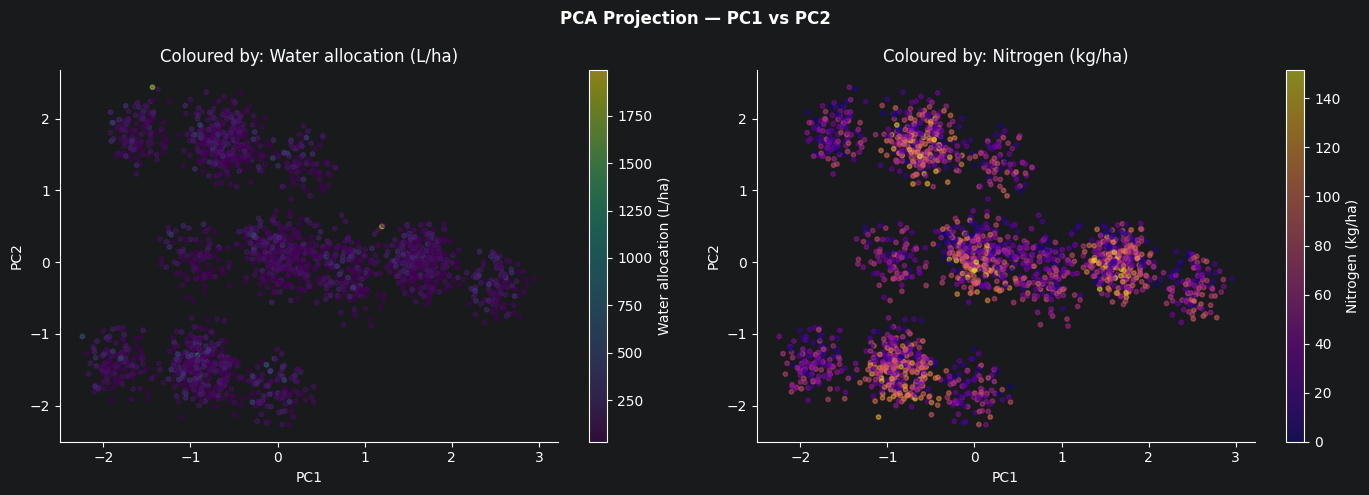

In [10]:
# ── Cell 10 : PCA biplot — PC1 vs PC2 coloured by water allocation ────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Projection — PC1 vs PC2', fontsize=12, fontweight='bold')

targets_plot = [
    (y_water, 'Water allocation (L/ha)', 'viridis'),
    (y_N,     'Nitrogen (kg/ha)',         'plasma'),
]

for ax, (target, label, cmap) in zip(axes, targets_plot):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=target, cmap=cmap, alpha=0.5, s=10)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Coloured by: {label}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fe_pca_biplot.png', dpi=120)
plt.show()

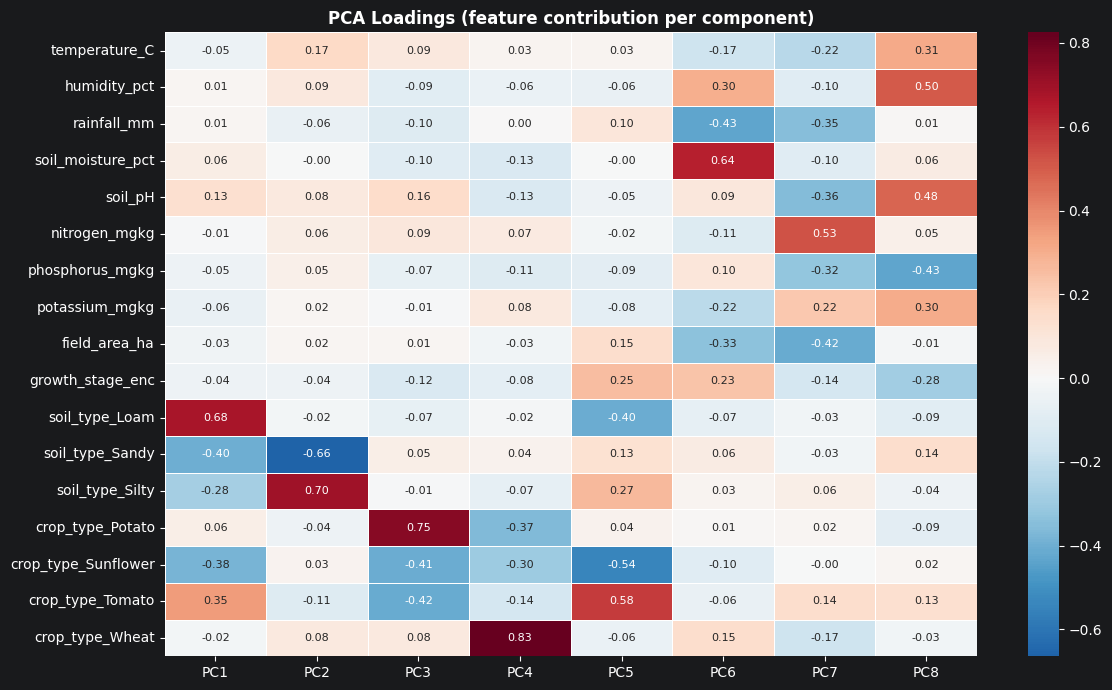

In [11]:
# ── Cell 11 : PCA loadings heatmap — which features drive each component ──────

loadings = pd.DataFrame(
    pca.components_[:8].T,          # show first 8 PCs max
    index=FEATURE_COLS,
    columns=[f'PC{i+1}' for i in range(min(8, n_components_95))]
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    loadings, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('PCA Loadings (feature contribution per component)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fe_pca_loadings.png', dpi=120)
plt.show()

---
## Part C — LDA (Linear Discriminant Analysis) — adapted for regression

> LDA is originally a **classification** technique. For our **regression** problem we adapt it by:
> 1. Discretising each continuous target into bins (low / medium / high)
> 2. Applying LDA to find projections that maximally separate those bins
> 3. Using the LDA-projected features as an additional feature set for comparison
>
> This is a standard academic approach to apply LDA in regression contexts.

In [12]:
# ── Cell 12 : Discretise targets into 3 classes (low / medium / high) ─────────

discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

y_water_disc = discretizer.fit_transform(y_water.reshape(-1,1)).ravel().astype(int)
y_N_disc     = discretizer.fit_transform(y_N.reshape(-1,1)).ravel().astype(int)
y_P_disc     = discretizer.fit_transform(y_P.reshape(-1,1)).ravel().astype(int)

class_labels = ['Low', 'Medium', 'High']
print("Water allocation class distribution:")
unique, counts = np.unique(y_water_disc, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_labels[u]:<8}: {c} samples ({c/len(y_water_disc)*100:.1f}%)")

Water allocation class distribution:
  Low     : 661 samples (33.2%)
  Medium  : 665 samples (33.4%)
  High    : 663 samples (33.3%)


In [13]:
# ── Cell 13 : Apply LDA for each discretised target ───────────────────────────
#
# With 3 classes, LDA gives at most 2 discriminant components (n_classes - 1).
# ─────────────────────────────────────────────────────────────────────────────

lda_water = LDA(n_components=2)
lda_N     = LDA(n_components=2)
lda_P     = LDA(n_components=2)

X_lda_water = lda_water.fit_transform(X, y_water_disc)
X_lda_N     = lda_N.fit_transform(X, y_N_disc)
X_lda_P     = lda_P.fit_transform(X, y_P_disc)

print("LDA projection shapes:")
print(f"  Water allocation : {X_lda_water.shape}")
print(f"  Nitrogen (N)     : {X_lda_N.shape}")
print(f"  Phosphorus (P)   : {X_lda_P.shape}")

print()
print("LDA explained variance ratio (water allocation):")
print(lda_water.explained_variance_ratio_.round(4))

LDA projection shapes:
  Water allocation : (1989, 2)
  Nitrogen (N)     : (1989, 2)
  Phosphorus (P)   : (1989, 2)

LDA explained variance ratio (water allocation):
[0.9916 0.0084]


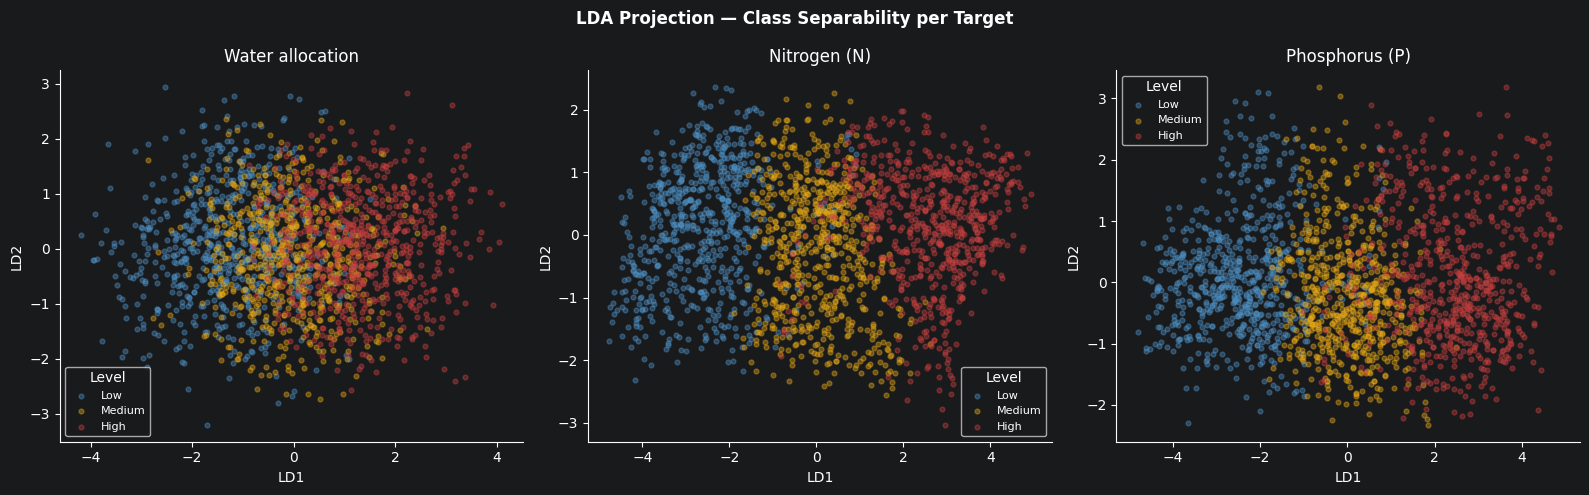

In [14]:
# ── Cell 14 : Visualise LDA projections ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LDA Projection — Class Separability per Target', fontsize=12, fontweight='bold')

setups = [
    (X_lda_water, y_water_disc, 'Water allocation', ['#4e91c4', '#e6a817', '#c94040']),
    (X_lda_N,     y_N_disc,     'Nitrogen (N)',     ['#4e91c4', '#e6a817', '#c94040']),
    (X_lda_P,     y_P_disc,     'Phosphorus (P)',   ['#4e91c4', '#e6a817', '#c94040']),
]

for ax, (X_lda, y_disc, title, colors) in zip(axes, setups):
    for cls_idx, (label, color) in enumerate(zip(class_labels, colors)):
        mask = y_disc == cls_idx
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   alpha=0.4, s=12, color=color, label=label)
    ax.set_xlabel('LD1')
    ax.set_ylabel('LD2')
    ax.set_title(title)
    ax.legend(fontsize=8, title='Level')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fe_lda_projection.png', dpi=120)
plt.show()

In [15]:
# ── Cell 15 : Compare all projection methods — variance retained summary ───────

print("=" * 55)
print("   FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"  Original dimensions            : {X.shape[1]}")
print()
print("  Feature Selection (consensus)")
print(f"    → {len(consensus_features)} features kept: {sorted(consensus_features)}")
print()
print("  PCA (95% variance threshold)")
print(f"    → {n_components_95} components")
print(f"    → Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"    → Dimension reduction: {X.shape[1]} → {n_components_95}")
print()
print("  LDA (adapted for regression via discretisation)")
print(f"    → 2 discriminant components per target")
print(f"    → 3 LDA projections: water / N / P")
print()
print("  Datasets prepared for training:")
print(f"    X            — full features    shape {X.shape}")
print(f"    X_selected   — best features    shape {X_selected.shape}")
print(f"    X_pca        — PCA projected    shape {X_pca.shape}")
print(f"    X_lda_water  — LDA (water)      shape {X_lda_water.shape}")
print("=" * 55)

   FEATURE ENGINEERING SUMMARY
  Original dimensions            : 17

  Feature Selection (consensus)
    → 6 features kept: ['growth_stage_enc', 'nitrogen_mgkg', 'phosphorus_mgkg', 'rainfall_mm', 'soil_moisture_pct', 'temperature_C']

  PCA (95% variance threshold)
    → 15 components
    → Variance retained: 96.67%
    → Dimension reduction: 17 → 15

  LDA (adapted for regression via discretisation)
    → 2 discriminant components per target
    → 3 LDA projections: water / N / P

  Datasets prepared for training:
    X            — full features    shape (1989, 17)
    X_selected   — best features    shape (1989, 6)
    X_pca        — PCA projected    shape (1989, 15)
    X_lda_water  — LDA (water)      shape (1989, 2)


In [16]:
# ── Cell 16 : Save all projected datasets ─────────────────────────────────────
import os
os.makedirs('datasets', exist_ok=True)

# PCA
df_pca_out = pd.DataFrame(X_pca, columns=pca_cols)
for col, vals in zip(TARGET_COLS, [y_water, y_N, y_P]):
    df_pca_out[col] = vals
df_pca_out.to_csv('datasets/dataset1_pca.csv', index=False)

# Selected features
df_sel_out = pd.DataFrame(X_selected, columns=consensus_features)
for col, vals in zip(TARGET_COLS, [y_water, y_N, y_P]):
    df_sel_out[col] = vals
df_sel_out.to_csv('datasets/dataset1_selected.csv', index=False)

# LDA projections
df_lda_out = pd.DataFrame({
    'LD1_water': X_lda_water[:, 0], 'LD2_water': X_lda_water[:, 1],
    'LD1_N':     X_lda_N[:, 0],     'LD2_N':     X_lda_N[:, 1],
    'LD1_P':     X_lda_P[:, 0],     'LD2_P':     X_lda_P[:, 1],
})
for col, vals in zip(TARGET_COLS, [y_water, y_N, y_P]):
    df_lda_out[col] = vals
df_lda_out.to_csv('datasets/dataset1_lda.csv', index=False)

print("Saved:")
print("  datasets/dataset1_pca.csv       (PCA projected features + targets)")
print("  datasets/dataset1_selected.csv  (consensus selected features + targets)")
print("  datasets/dataset1_lda.csv       (LDA projected features + targets)")

Saved:
  datasets/dataset1_pca.csv       (PCA projected features + targets)
  datasets/dataset1_selected.csv  (consensus selected features + targets)
  datasets/dataset1_lda.csv       (LDA projected features + targets)


---
## Feature Engineering checklist

| Technique | Method | Tool | Output |
|---|---|---|---|
| Low-variance removal | VarianceThreshold | sklearn | Filtered X |
| Correlation analysis | Pearson r vs targets | pandas | Ranked list |
| Univariate selection | F-regression (SelectKBest) | sklearn | Top-K features |
| Importance ranking | RandomForest multi-output | sklearn | Importance scores |
| Consensus selection | RF ∩ SelectKBest | python set | X_selected |
| **PCA** | 95% variance threshold | sklearn | X_pca |
| **LDA** | Adapted via discretisation | sklearn | X_lda |

**Next step → Data Splitting (Train/Val/Test + K-Fold Cross Validation)**